In [1]:
import lsdb
from upath import UPath
from dask.distributed import Client
from lsdb.streams import CatalogStream

In [2]:
print(lsdb.__version__)

0.10.0


# Using LSDB to Perform Crossmatches with Data Preview 2 (DP2)

In this notebook we'll show how to:

* Load the hats-formatted version of DP2 on the Rubin Science Platform (RSP)
* Load an external hats catalogs
* View hats pixel distribution of catalogs
* Apply column-based filtering on catalogs
* Perform crossmatching between DP2 and other catalogs
* Counting the resulting matches with `Catalog.map_partitions`
* Show how to begin actual computation

## Load Data Preview 2

In [3]:
dp2_path = "/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2_rc/object_collection" # replace with proper DP2 path
#dp2_path = UPath("/rubin/lsdb_data/object_collection")

dp2 = lsdb.open_catalog(dp2_path, columns=["coord_ra", "coord_dec"])
dp2

,coord_ra,coord_dec
npartitions=8840,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow]
"Order: 8, Pixel: 10241",...,...
...,...,...
"Order: 5, Pixel: 12283",...,...
"Order: 5, Pixel: 12284",...,...


/home/b/brantd/.conda/envs/operations_rrl/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - object_lc'}>)

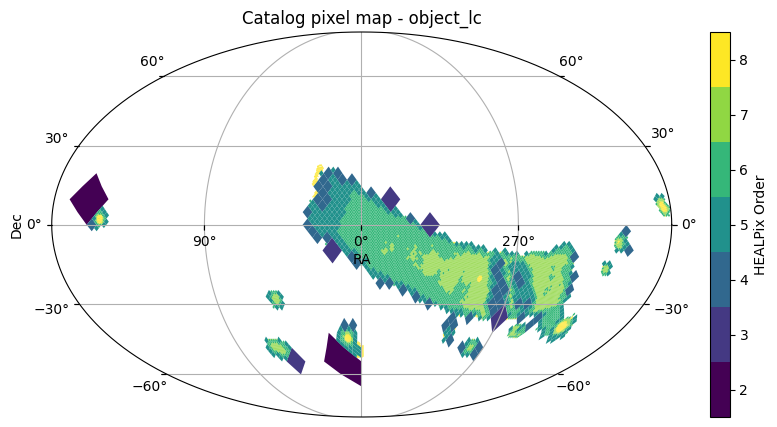

In [4]:
dp2.plot_pixels()

## Load another Catalog - Gaia DR3

In [5]:
# Open from a remote s3 bucket
gaia = lsdb.open_catalog('s3://stpubdata/gaia/gaia_dr3/public/hats',
                        columns=["ra", "dec", "parallax", 'parallax_over_error', 'teff_gspphot', 'logg_gspphot', 'classprob_dsc_combmod_star'])
gaia

,ra,dec,parallax,parallax_over_error,teff_gspphot,logg_gspphot,classprob_dsc_combmod_star
npartitions=2016,,,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow]
"Order: 2, Pixel: 1",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...,...


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - gaia'}>)

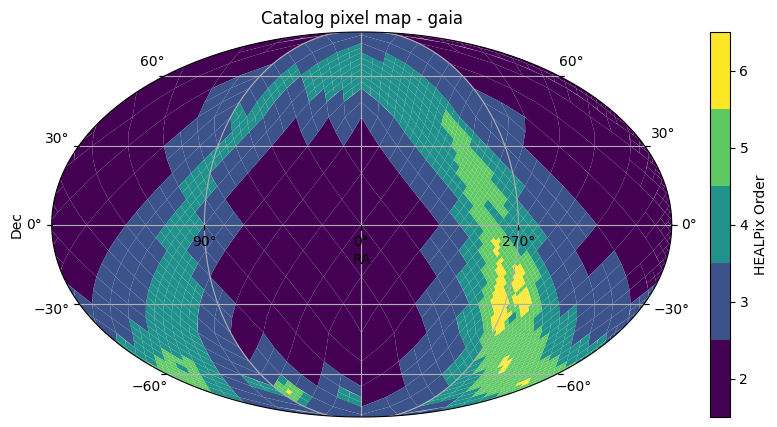

In [6]:
gaia.plot_pixels()

### Query Gaia: Filtering for FGK Stars

In [7]:
gaia_filtered = gaia.query(
    "parallax > 0 and parallax_over_error > 5 and \
    teff_gspphot > 5380 and teff_gspphot < 7220 and logg_gspphot > 4.5 \
    and logg_gspphot < 4.72 and classprob_dsc_combmod_star > 0.5"
)

### Perform a Crossmatch

In [8]:
xmatch = dp2.crossmatch(gaia_filtered, suffix_method="overlapping_columns")
xmatch

,coord_ra,coord_dec,ra,dec,parallax,parallax_over_error,teff_gspphot,logg_gspphot,classprob_dsc_combmod_star,_dist_arcsec
npartitions=9139,,,,,,,,,,
"Order: 8, Pixel: 10240",double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow]
"Order: 8, Pixel: 10241",...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12284",...,...,...,...,...,...,...,...,...,...


## Count the Resulting Matches

In [9]:
# Write a simple map_partitions function to count resulting matches
def count_matches(df):
    return {"n_matches": len(df)}

matches_by_partition = xmatch.map_partitions(count_matches)

## Performing Computation

In [ ]:
# Define a client, and .compute() the match result
with Client(n_workers=4, threads_per_worker=1, memory_limit="4GB") as client:
    match_df = matches_by_partition.compute()
    client.close()

In [14]:
print(f"Number of Matches: {match_df["n_matches"].sum()}")

Number of Matches: 548168


### Alternatively, Stream the Computation

In [12]:
%%time
match_stream = CatalogStream(matches_by_partition, partitions_per_chunk=1000)

chunks = []
with Client(n_workers=4, memory_limit="4GB") as client:
    for i, chunk in enumerate(match_stream):
        chunks.append(chunk)
        
    client.close()
print(f"Number of Matches: {sum([chunk.sum() for chunk in chunks])}")

Number of Matches: n_matches    548168
dtype: int64
CPU times: user 3min 25s, sys: 21.1 s, total: 3min 46s
Wall time: 21min 59s
